In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kagglehub
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
import os

DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

print(os.listdir(DATASET_PATH))

['Training', 'Testing']


In [ ]:
train_dir = os.path.join(DATASET_PATH, "Training")
test_dir = os.path.join(DATASET_PATH, "Testing")

print("Training Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Classes:
['pituitary', 'notumor', 'meningioma', 'glioma']

Testing Classes:
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

Found 4480 images belonging to 4 classes.


In [ ]:
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 1120 images belonging to 4 classes.


In [ ]:
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,045,572 (57.39 MB)

 Trainable params: 329,860 (1.26 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

Training VGG16 (Frozen Base)...
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.4644 - loss: 1.2849
Epoch 1: val_accuracy improved from None to 0.75625, saving model to best_vgg.keras

Epoch 1: finished saving model to best_vgg.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 115s 712ms/step - accuracy: 0.5857 - loss: 1.0055 - val_accuracy: 0.7563 - val_loss: 1.1321 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7390 - loss: 0.6690
Epoch 2: val_accuracy improved from 0.75625 to 0.81518, saving model to best_vgg.keras

Epoch 2: finished saving model to best_vgg.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 570ms/step - accuracy: 0.7446 - loss: 0.6495 - val_accuracy: 0.8152 - val_loss: 0.8014 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.7786 - loss: 0.5986
Epoch 3: val_accuracy improved from 0.81518 to 0.85268, saving model to best_vgg.keras

Epoch 3: finished saving model to best_vgg.keras

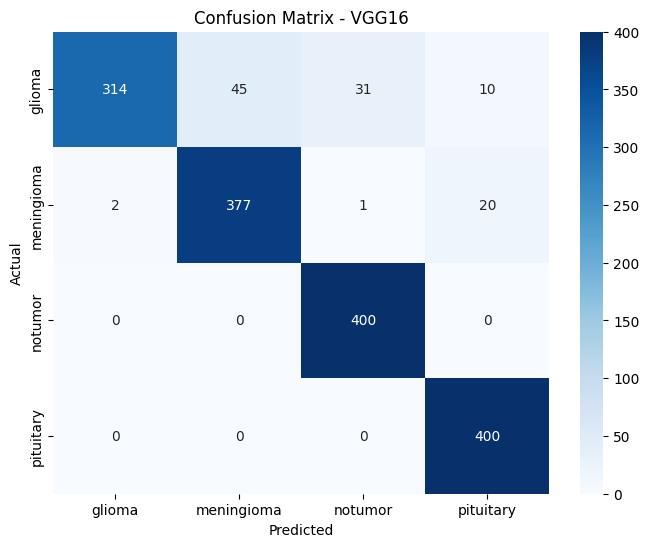

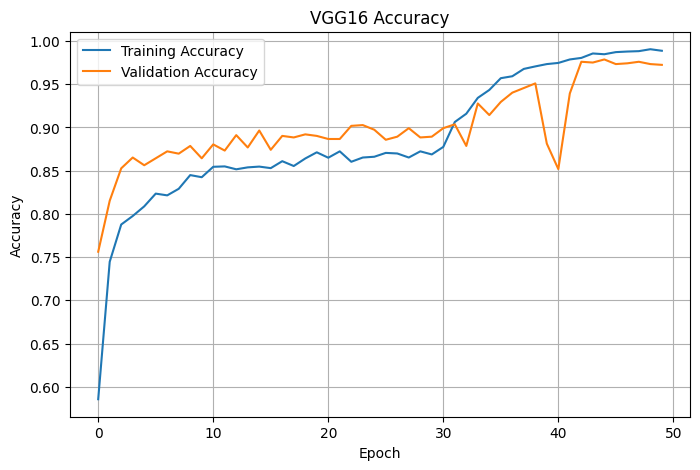

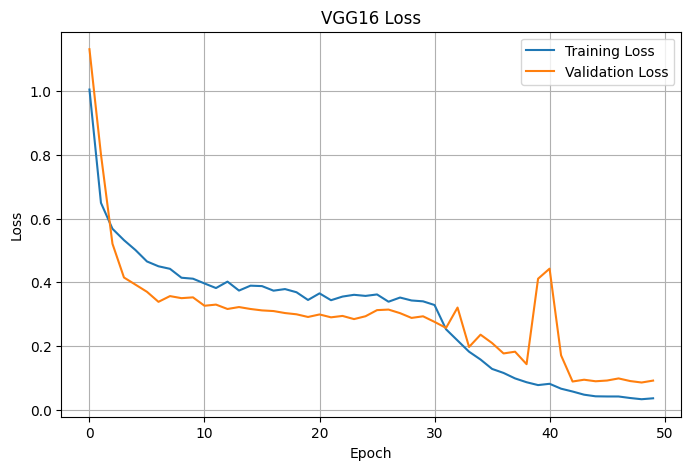

VGG16 MODEL TRAINING COMPLETED SUCCESSFULLY
Saved Model : vgg16_finetuned.keras
Best Model  : best_vgg.keras


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===================================================
# Build VGG16 Model
# ===================================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(4, activation="softmax")(x)

vgg_model = Model(inputs, outputs)

vgg_model.summary()

# ===================================================
# Compile
# ===================================================

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ===================================================
# Callbacks
# ===================================================

callbacks_vgg = [

    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_vgg.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

]

# ===================================================
# Frozen Training
# ===================================================

print("Training VGG16 (Frozen Base)...")

history_vgg = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_vgg,
    verbose=1
)

# ===================================================
# Fine Tuning
# ===================================================

print("Fine Tuning Started...")

base_model.trainable = True

for layer in base_model.layers[:-8]:
    layer.trainable = False

vgg_model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_vgg_ft = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_vgg,
    verbose=1
)

# ===================================================
# Save Model
# ===================================================

vgg_model.save("vgg16_finetuned.keras")

# ===================================================
# Evaluate
# ===================================================

test_loss, test_acc = vgg_model.evaluate(test_gen)

print("="*60)
print("Test Accuracy :", test_acc)
print("Test Loss     :", test_loss)
print("="*60)

# ===================================================
# Prediction
# ===================================================

pred = vgg_model.predict(test_gen)

y_pred = np.argmax(pred, axis=1)

y_true = test_gen.classes

# ===================================================
# Classification Report
# ===================================================

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

# ===================================================
# Confusion Matrix
# ===================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_gen.class_indices.keys(),
    yticklabels=test_gen.class_indices.keys()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16")

plt.show()

# ===================================================
# Accuracy Plot
# ===================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history["accuracy"] +
    history_vgg_ft.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_vgg.history["val_accuracy"] +
    history_vgg_ft.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ===================================================
# Loss Plot
# ===================================================

plt.figure(figsize=(8,5))

plt.plot(
    history_vgg.history["loss"] +
    history_vgg_ft.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_vgg.history["val_loss"] +
    history_vgg_ft.history["val_loss"],
    label="Validation Loss"
)

plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

print("="*60)
print("VGG16 MODEL TRAINING COMPLETED SUCCESSFULLY")
print("="*60)
print("Saved Model : vgg16_finetuned.keras")
print("Best Model  : best_vgg.keras")
print("="*60)

In [ ]:
import os
import shutil

# Create output folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

# Save trained models
if os.path.exists("best_vgg.keras"):
    shutil.copy("best_vgg.keras", "models/best_vgg.keras")

if os.path.exists("vgg16_finetuned.keras"):
    shutil.copy("vgg16_finetuned.keras", "models/vgg16_finetuned.keras")


print("===================================")
print("All files saved successfully!")
print("Models  -> models/")
print("Images  -> outputs/")
print("===================================")

All files saved successfully!
Models  -> models/
Images  -> outputs/


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
import zipfile
import os

zip_name = "BrainTumor_VGG16_Project.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["models", "outputs"]:
        for root, dirs, files in os.walk(folder):
            for file in files:
                path = os.path.join(root, file)
                zipf.write(path)

print("ZIP created:", zip_name)

ZIP created: BrainTumor_VGG16_Project.zip
